In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [2]:
df = pd.read_csv("GEFCom2014_prepared.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "hour"]).reset_index(drop=True)

df["hour"] = df["hour"].astype(int) - 1
df["day_of_week"] = df["day_of_week"].astype(int)
df["month"] = df["month"].astype(int) - 1
df["is_weekend"] = df["is_weekend"].astype(int)

In [ ]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']

zone_cols = [
    "zone_residential",
    "zone_commercial",
    "zone_industrial"
]

In [ ]:
SEQ_LEN = 24

class DatasetRQ6(Dataset):

    def __init__(self, df):

        self.Xl = df[load_features].values.astype(np.float32)

        self.Xt = df[temp_features].values.astype(np.float32)

        self.Xc = df[calendar_features].values.astype(np.int64)

        # MULTI-ZONE TARGETS
        self.y = df[zone_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.Xl) - SEQ_LEN

    def __getitem__(self, idx):

        return (

            torch.tensor(self.Xl[idx:idx+SEQ_LEN]),

            torch.tensor(self.Xt[idx:idx+SEQ_LEN]),

            torch.tensor(self.Xc[idx:idx+SEQ_LEN]),

            torch.tensor(self.y[idx+SEQ_LEN])

        )

In [ ]:
class JointMultimodalBaseline(nn.Module):

    def __init__(self, num_zones):
        super().__init__()

        # =====================================================
        # LOAD ENCODER
        # =====================================================
        self.lstm = nn.LSTM(
            input_size=len(load_features),
            hidden_size=64,
            batch_first=True
        )

        # =====================================================
        # TEMPERATURE ENCODER
        # =====================================================
        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # =====================================================
        # CALENDAR EMBEDDINGS
        # =====================================================
        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        # =====================================================
        # SHARED MULTIMODAL REPRESENTATION
        # =====================================================
        self.fc = nn.Sequential(

            nn.Linear(64 + 32 + 18, 64),
            nn.ReLU(),

            # Multi-zone prediction head
            nn.Linear(64, num_zones)

        )

    def forward(self, Xl, Xt, Xc):

        # =====================================================
        # LOAD FEATURES
        # =====================================================
        _, (h, _) = self.lstm(Xl)

        load_out = h[-1]          # (B,64)

        # =====================================================
        # TEMPERATURE FEATURES
        # =====================================================
        temp_out = self.temp_mlp(
            Xt[:, -1, :]
        )                         # (B,32)

        # =====================================================
        # CALENDAR FEATURES
        # =====================================================
        cal_out = torch.cat([

            self.hour_emb(Xc[:, -1, 0]),
            self.day_emb(Xc[:, -1, 1]),
            self.month_emb(Xc[:, -1, 2]),
            self.weekend_emb(Xc[:, -1, 3])

        ], dim=1)                 # (B,18)

        # =====================================================
        # MULTIMODAL CONCATENATION
        # =====================================================
        fused = torch.cat([

            load_out,
            temp_out,
            cal_out

        ], dim=1)

        # =====================================================
        # MULTI-ZONE OUTPUTS
        # =====================================================
        out = self.fc(fused)

        # Output shape:
        # (B, num_zones)

        return out

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AdaptiveJointFusionModel(nn.Module):

    def __init__(self, num_zones):
        super().__init__()

        # =====================================================
        # LOAD ENCODER
        # =====================================================
        self.lstm = nn.LSTM(
            input_size=len(load_features),
            hidden_size=64,
            batch_first=True
        )

        # =====================================================
        # TEMPERATURE ENCODER
        # =====================================================
        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # =====================================================
        # CALENDAR EMBEDDINGS
        # =====================================================
        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        # =====================================================
        # FEATURE DIMENSIONS
        # =====================================================
        self.load_dim = 64
        self.temp_dim = 32
        self.cal_dim = 18

        self.total_dim = (
            self.load_dim +
            self.temp_dim +
            self.cal_dim
        )

        # =====================================================
        # ADAPTIVE ATTENTION NETWORK
        # =====================================================
        self.attention = nn.Sequential(
            nn.Linear(self.total_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

        # =====================================================
        # SHARED LATENT REPRESENTATION
        # =====================================================
        self.shared_representation = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.ReLU()
        )

        # =====================================================
        # MULTI-ZONE OUTPUT HEAD
        # =====================================================
        self.output_head = nn.Linear(64, num_zones)

    def forward(self, Xl, Xt, Xc):

        # =====================================================
        # LOAD ENCODING
        # =====================================================
        _, (h, _) = self.lstm(Xl)

        load_out = h[-1]                  # (B,64)

        # =====================================================
        # TEMPERATURE ENCODING
        # =====================================================
        temp_out = self.temp_mlp(
            Xt[:, -1, :]
        )                                 # (B,32)

        # =====================================================
        # CALENDAR ENCODING
        # =====================================================
        cal_out = torch.cat([

            self.hour_emb(Xc[:, -1, 0]),
            self.day_emb(Xc[:, -1, 1]),
            self.month_emb(Xc[:, -1, 2]),
            self.weekend_emb(Xc[:, -1, 3])

        ], dim=1)                         # (B,18)

        # =====================================================
        # FEATURE NORMALIZATION
        # =====================================================
        load_out = F.layer_norm(
            load_out,
            load_out.shape[1:]
        )

        temp_out = F.layer_norm(
            temp_out,
            temp_out.shape[1:]
        )

        cal_out = F.layer_norm(
            cal_out,
            cal_out.shape[1:]
        )

        # =====================================================
        # CONCATENATED REPRESENTATION
        # =====================================================
        combined = torch.cat([
            load_out,
            temp_out,
            cal_out
        ], dim=1)

        # =====================================================
        # ATTENTION WEIGHTS
        # =====================================================
        logits = self.attention(combined)

        # Temperature scaling stabilizes softmax
        weights = torch.softmax(
            logits / 2.0,
            dim=1
        )

        # =====================================================
        # SPLIT ATTENTION WEIGHTS
        # =====================================================
        w_load = weights[:, 0].unsqueeze(1)
        w_temp = weights[:, 1].unsqueeze(1)
        w_cal  = weights[:, 2].unsqueeze(1)

        # =====================================================
        # ADAPTIVE MULTIMODAL FUSION
        # =====================================================
        fused = torch.cat([

            load_out * w_load,
            temp_out * w_temp,
            cal_out * w_cal

        ], dim=1)

        # =====================================================
        # RESIDUAL CONNECTION
        # =====================================================
        fused = fused + combined

        # =====================================================
        # SHARED LATENT REPRESENTATION
        # =====================================================
        shared_features = self.shared_representation(fused)

        # =====================================================
        # MULTI-ZONE FORECASTS
        # =====================================================
        out = self.output_head(shared_features)

        # out shape:
        # (B, num_zones)

        return out, weights

In [ ]:
def train_model(model, train_loader, epochs=20):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.MSELoss()

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for Xl, Xt, Xc, y in train_loader:

            Xl = Xl.to(device)
            Xt = Xt.to(device)
            Xc = Xc.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            # ---------------------------------
            # Adaptive model
            # ---------------------------------
            if isinstance(model, AdaptiveJointFusionModel):

                preds, _ = model(Xl, Xt, Xc)

            # ---------------------------------
            # Baseline model
            # ---------------------------------
            else:

                preds = model(Xl, Xt, Xc)

            loss = criterion(preds, y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch {epoch+1} | Loss: {total_loss:.4f}"
        )

In [ ]:
def evaluate_adaptive(model, loader):

    model.eval()

    preds = []
    actuals = []
    weights_list = []

    with torch.no_grad():

        for Xl, Xt, Xc, y in loader:

            Xl = Xl.to(device)
            Xt = Xt.to(device)
            Xc = Xc.to(device)

            out, weights = model(Xl, Xt, Xc)

            preds.append(
                out.cpu().numpy()
            )

            actuals.append(
                y.numpy()
            )

            weights_list.append(
                weights.cpu().numpy()
            )

    return (

        np.vstack(preds),
        np.vstack(actuals),
        np.vstack(weights_list)

    )

In [ ]:
dataset = DatasetRQ6(df)

train_size = int(0.8 * len(dataset))
train_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, len(dataset) - train_size]
)

train_loader = DataLoader(train_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [ ]:
baseline_model = JointMultimodalBaseline(
    num_zones=len(zone_cols)
).to(device)

adaptive_model = AdaptiveJointFusionModel(
    num_zones=len(zone_cols)
).to(device)

In [24]:
print("Training Baseline Model...")
train_model(baseline_model, train_loader)

print("\nTraining Adaptive Fusion Model...")
train_model(adaptive_model, train_loader)

Training Baseline Model...
Epoch 1 | Loss: 994753898.6562
Epoch 2 | Loss: 124937249.1641
Epoch 3 | Loss: 41703798.9912
Epoch 4 | Loss: 28893320.8164
Epoch 5 | Loss: 26499858.7354
Epoch 6 | Loss: 25103850.3789
Epoch 7 | Loss: 24207319.3350
Epoch 8 | Loss: 23583749.6768
Epoch 9 | Loss: 22985593.1387
Epoch 10 | Loss: 22592914.8291
Epoch 11 | Loss: 22256163.5273
Epoch 12 | Loss: 22084146.4199
Epoch 13 | Loss: 22053513.0908
Epoch 14 | Loss: 21619621.7500
Epoch 15 | Loss: 21663453.6094
Epoch 16 | Loss: 21507019.2891
Epoch 17 | Loss: 21520555.1221
Epoch 18 | Loss: 21361493.2744
Epoch 19 | Loss: 21237969.8887
Epoch 20 | Loss: 21344820.8145

Training Adaptive Fusion Model...
Epoch 1 | Loss: 3762529362.9062
Epoch 2 | Loss: 75085161.7217
Epoch 3 | Loss: 28232135.1484
Epoch 4 | Loss: 21950587.8438
Epoch 5 | Loss: 18489750.8057
Epoch 6 | Loss: 16289904.7251
Epoch 7 | Loss: 15270414.7354
Epoch 8 | Loss: 14654032.4775
Epoch 9 | Loss: 14424791.5815
Epoch 10 | Loss: 14056609.0654
Epoch 11 | Loss: 13976

In [ ]:
def evaluate_baseline(model, loader):

    model.eval()

    preds = []
    actuals = []

    with torch.no_grad():

        for Xl, Xt, Xc, y in loader:

            Xl = Xl.to(device)
            Xt = Xt.to(device)
            Xc = Xc.to(device)

            out = model(Xl, Xt, Xc)

            preds.append(
                out.cpu().numpy()
            )

            actuals.append(
                y.numpy()
            )

    return (
        np.vstack(preds),
        np.vstack(actuals)
    )

In [26]:
# Baseline
preds_baseline, actuals = evaluate_baseline(baseline_model, test_loader)

# Adaptive
preds_adaptive, actuals_adapt, weights = evaluate_adaptive(adaptive_model, test_loader)

In [ ]:
baseline_mae = []
adaptive_mae = []

baseline_rmse = []
adaptive_rmse = []

for i in range(len(zone_cols)):

    # -----------------------------
    # BASELINE
    # -----------------------------
    b_mae = mean_absolute_error(
        actuals[:, i],
        preds_baseline[:, i]
    )

    b_rmse = np.sqrt(
        mean_squared_error(
            actuals[:, i],
            preds_baseline[:, i]
        )
    )

    # -----------------------------
    # ADAPTIVE
    # -----------------------------
    a_mae = mean_absolute_error(
        actuals[:, i],
        preds_adaptive[:, i]
    )

    a_rmse = np.sqrt(
        mean_squared_error(
            actuals[:, i],
            preds_adaptive[:, i]
        )
    )

    baseline_mae.append(b_mae)
    adaptive_mae.append(a_mae)

    baseline_rmse.append(b_rmse)
    adaptive_rmse.append(a_rmse)
    

results = pd.DataFrame({

    "Zone": zone_cols,

    "Baseline_MAE": baseline_mae,
    "Adaptive_MAE": adaptive_mae,

    "Baseline_RMSE": baseline_rmse,
    "Adaptive_RMSE": adaptive_rmse,

    "MAE_Improvement":
        np.array(baseline_mae)
        - np.array(adaptive_mae)

})

results.to_csv(
    "outputs/tables/rq6_results.csv",
    index=False
)

results

,Model,MAE,RMSE
0,Baseline,107.522934,144.280935
1,Adaptive Fusion,85.828156,119.443297


In [29]:
avg_weights = weights.mean(axis=0)

attention_df = pd.DataFrame({
    "Modality": ["Load", "Temperature", "Calendar"],
    "Average Weight": avg_weights
})

attention_df.to_csv("outputs/tables/rq6_attention_weights.csv", index=False)
attention_df

,Modality,Average Weight
0,Load,0.341764
1,Temperature,0.057096
2,Calendar,0.601140


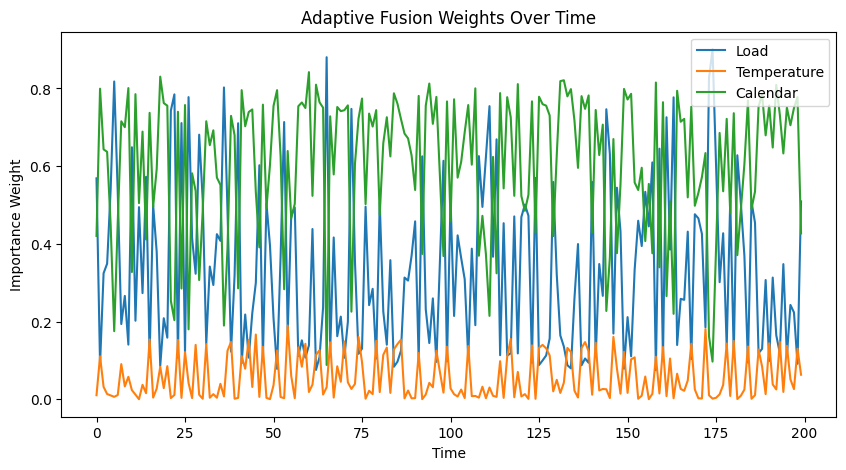

In [30]:
plt.figure(figsize=(10,5))

plt.plot(weights[:200, 0], label="Load")
plt.plot(weights[:200, 1], label="Temperature")
plt.plot(weights[:200, 2], label="Calendar")

plt.legend()
plt.title("Adaptive Fusion Weights Over Time")
plt.xlabel("Time")
plt.ylabel("Importance Weight")

plt.savefig("outputs/figures/rq6_attention_over_time.pdf")
plt.show()

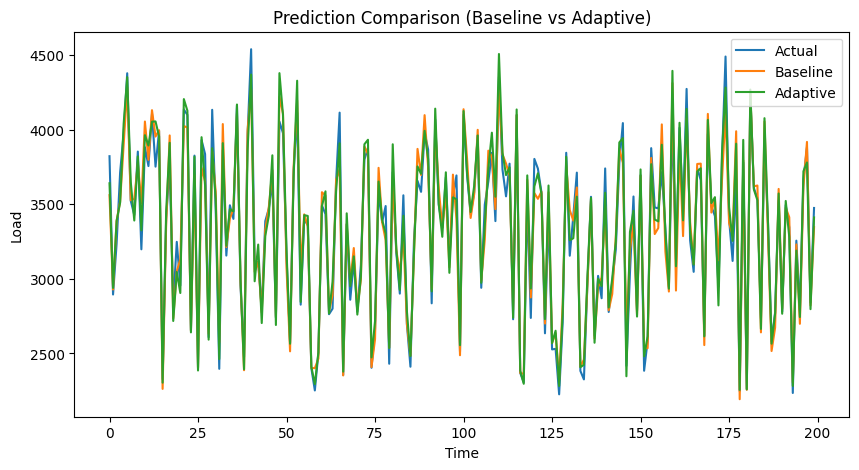

In [ ]:
# =====================================================
# ZONE-SPECIFIC PREDICTION COMPARISON
# =====================================================

zone_idx = 0

zone_name = zone_cols[zone_idx]

plt.figure(figsize=(12,5))

# ---------------------------------
# ACTUAL
# ---------------------------------
plt.plot(
    actuals[:200, zone_idx],
    label="Actual"
)

# ---------------------------------
# BASELINE
# ---------------------------------
plt.plot(
    preds_baseline[:200, zone_idx],
    label="Baseline"
)

# ---------------------------------
# ADAPTIVE
# ---------------------------------
plt.plot(
    preds_adaptive[:200, zone_idx],
    label="Adaptive Fusion"
)

# ---------------------------------
# SETTINGS
# ---------------------------------
plt.legend()

plt.title(
    f"Forecast Comparison for {zone_name}"
)

plt.xlabel("Time Step")

plt.ylabel("Electricity Load")

plt.grid(alpha=0.3)

plt.tight_layout()

# ---------------------------------
# SAVE
# ---------------------------------
plt.savefig(
    "outputs/figures/rq6_predictions.pdf"
)

plt.show()